# Factor Signals

First pass at turning the raw data into candidate signals for predicting
forward ETF returns, and checking whether any of them carry information
before building a model on top of them. Two families of factors:

1. **Cross-asset FX risk reversals** — first explored with an
   economically-motivated pairing (not exhaustive):
   - `EURUSD25R1M` -> `EZU` (eurozone equities, EUR-sensitive)
   - `USDJPY25R1M` -> `EWJ` (Japan equities, JPY-sensitive)
   - `EURJPY25R1M` -> both `EZU` and `EWJ` as a secondary/cross-check feature

   This pairing is later refined into a **local-currency-demand** framing
   (see that section below) that sign-corrects each risk reversal so it
   consistently means "demand for this ETF's own currency," and — as a
   consequence — gives `SPY` an FX-based feature for the first time, since
   USD ends up being the base currency of one of the two pairs it's paired
   with.
2. **Own-asset price, volume, and volatility-index factors** — each
   ETF against its own price/volume history and its own regional
   volatility index:
   - `SPY` <-> `VIX Index`
   - `EZU` <-> `V2X Index`
   - `EWJ` <-> `NKYVF Index`

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load and merge

In [2]:
idx = pd.read_csv("data/Index_ETF_Data_Clean.csv", parse_dates=["Dates"])
rr = pd.read_csv("data/RiskReversalData_Clean.csv", parse_dates=["Dates"])

df = idx.merge(rr, on="Dates", how="inner").sort_values("Dates").set_index("Dates")

rr_cols = {
    "EURUSD25R1M": "EURUSD25R1M BGN Curncy (R1)",
    "USDJPY25R1M": "USDJPY25R1M BGN Curncy (R2)",
    "EURJPY25R1M": "EURJPY25R1M BGN Curncy (L1)",
}

etf_cols = {
    "SPY": {
        "price": "SPY US Equity PX_LAST",
        "volume": "SPY US Equity PX_VOLUME",
        "vol_index": "VIX Index PX_LAST",
    },
    "EZU": {
        "price": "EZU US Equity PX_LAST",
        "volume": "EZU US Equity PX_VOLUME",
        "vol_index": "V2X Index PX_LAST",
    },
    "EWJ": {
        "price": "EWJ US Equity PX_LAST",
        "volume": "EWJ US Equity PX_VOLUME",
        "vol_index": "NKYVF Index PX_LAST",
    },
}

horizons = [1, 5, 20]

df.shape

(3762, 15)

## Risk-reversal features

For each risk reversal series, build a few candidate transforms:

- `level`: the raw risk reversal quote
- `chg_1d` / `chg_5d`: day-over-day and week-over-week change
- `zscore_60d`: level normalized by its own trailing 60-day mean/std, so the
  three series (which sit on different scales) are comparable

In [3]:
features = pd.DataFrame(index=df.index)

for name, col in rr_cols.items():
    level = df[col]
    features[f"{name}_level"] = level
    features[f"{name}_chg_1d"] = level.diff(1)
    features[f"{name}_chg_5d"] = level.diff(5)

    rolling_mean = level.rolling(60, min_periods=30).mean()
    rolling_std = level.rolling(60, min_periods=30).std()
    features[f"{name}_zscore_60d"] = (level - rolling_mean) / rolling_std

rr_feature_variants = ["level", "chg_1d", "chg_5d", "zscore_60d"]

features.tail(3)

,EURUSD25R1M_level,EURUSD25R1M_chg_1d,EURUSD25R1M_chg_5d,EURUSD25R1M_zscore_60d,USDJPY25R1M_level,USDJPY25R1M_chg_1d,USDJPY25R1M_chg_5d,USDJPY25R1M_zscore_60d,EURJPY25R1M_level,EURJPY25R1M_chg_1d,EURJPY25R1M_chg_5d,EURJPY25R1M_zscore_60d
Dates,,,,,,,,,,,,
2026-07-24,-0.5375,-0.0075,-0.1175,-0.877925,-1.4000,-0.0500,-0.0900,-0.730661,-1.450,-0.0375,-0.10,-0.992875
2026-07-27,-0.5825,-0.0450,-0.1525,-1.209951,-1.3650,0.0350,-0.0725,-0.630401,-1.395,0.0550,-0.05,-0.758215
2026-07-28,-0.6100,-0.0275,-0.1800,-1.384497,-1.3425,0.0225,-0.0825,-0.558465,-1.410,-0.0150,-0.12,-0.832757


## Local-currency-demand risk-reversal features

The three raw risk-reversal quotes each have a **base currency by naming
convention** (`EURUSD` -> EUR, `USDJPY` -> USD, `EURJPY` -> EUR is the first
currency in each pair), and a positive risk reversal means the market is
paying up for calls on that base currency — i.e. bullish demand for it.
That base currency is not always the ETF's own local currency, so the raw
`_level` features above measure "demand for whichever currency happens to
be listed first," not consistently "demand for this ETF's own currency."

To build a feature that means the same thing for every ETF — **demand for
this ETF's own local currency, versus each of the other two** — each raw
level is sign-flipped whenever the ETF's local currency is the *quote*
currency rather than the *base* currency of that pair:

| ETF | local currency | RR pair | base currency | sign applied |
|---|---|---|---|---|
| `EZU` | EUR | `EURUSD25R1M` | EUR | +1 |
| `EZU` | EUR | `EURJPY25R1M` | EUR | +1 |
| `EWJ` | JPY | `USDJPY25R1M` | USD | −1 |
| `EWJ` | JPY | `EURJPY25R1M` | EUR | −1 |
| `SPY` | USD | `EURUSD25R1M` | EUR | −1 |
| `SPY` | USD | `USDJPY25R1M` | USD | +1 |

Since every currency is the base in exactly one pair and the quote in the
other, this gives each ETF exactly two signed features, both interpretable
as "demand for my own currency" — and, as a side effect, gives `SPY` an
FX-based feature for the first time (previously it had none, since neither
raw pair's base currency was USD).

In [4]:
RR_BASE_CURRENCY = {"EURUSD25R1M": "EUR", "USDJPY25R1M": "USD", "EURJPY25R1M": "EUR"}
ETF_LOCAL_CURRENCY = {"SPY": "USD", "EZU": "EUR", "EWJ": "JPY"}
LOCAL_CURRENCY_RR_PAIRS = {
    "SPY": ["EURUSD25R1M", "USDJPY25R1M"],
    "EZU": ["EURUSD25R1M", "EURJPY25R1M"],
    "EWJ": ["USDJPY25R1M", "EURJPY25R1M"],
}

for etf, local_ccy in ETF_LOCAL_CURRENCY.items():
    for rr_name in LOCAL_CURRENCY_RR_PAIRS[etf]:
        sign = 1 if RR_BASE_CURRENCY[rr_name] == local_ccy else -1
        features[f"{etf}_{rr_name}_ccy_demand"] = sign * features[f"{rr_name}_level"]

features.filter(like="ccy_demand").tail(3)

,SPY_EURUSD25R1M_ccy_demand,SPY_USDJPY25R1M_ccy_demand,EZU_EURUSD25R1M_ccy_demand,EZU_EURJPY25R1M_ccy_demand,EWJ_USDJPY25R1M_ccy_demand,EWJ_EURJPY25R1M_ccy_demand
Dates,,,,,,
2026-07-24,0.5375,-1.4000,-0.5375,-1.450,1.4000,1.450
2026-07-27,0.5825,-1.3650,-0.5825,-1.395,1.3650,1.395
2026-07-28,0.6100,-1.3425,-0.6100,-1.410,1.3425,1.410


A quick IC check on these six new features (against each ETF's own forward
return) before they go anywhere near a model:

In [5]:
ccy_demand_rows = []
for etf, pairs in LOCAL_CURRENCY_RR_PAIRS.items():
    for rr_name in pairs:
        fcol = f"{etf}_{rr_name}_ccy_demand"
        for h in horizons:
            tcol = f"{etf}_fwd_ret_{h}d"
            paired = pd.concat(
                [features[fcol], df[etf_cols[etf]["price"]].shift(-h) / df[etf_cols[etf]["price"]] - 1],
                axis=1,
            ).dropna()
            paired.columns = [fcol, tcol]
            ccy_demand_rows.append({
                "etf": etf, "feature": fcol, "horizon": h, "n": len(paired),
                "pearson_ic": paired[fcol].corr(paired[tcol]),
                "spearman_ic": paired[fcol].corr(paired[tcol], method="spearman"),
            })

ccy_demand_diagnostics = pd.DataFrame(ccy_demand_rows)
ccy_demand_diagnostics.sort_values(["etf", "feature", "horizon"])

,etf,feature,horizon,n,pearson_ic,spearman_ic
15,EWJ,EWJ_EURJPY25R1M_ccy_demand,1,3761,0.028320,0.023326
16,EWJ,EWJ_EURJPY25R1M_ccy_demand,5,3757,0.086092,0.058875
17,EWJ,EWJ_EURJPY25R1M_ccy_demand,20,3742,0.171402,0.111554
12,EWJ,EWJ_USDJPY25R1M_ccy_demand,1,3761,0.018797,0.031644
13,EWJ,EWJ_USDJPY25R1M_ccy_demand,5,3757,0.068379,0.069730
14,EWJ,EWJ_USDJPY25R1M_ccy_demand,20,3742,0.174747,0.145787
9,EZU,EZU_EURJPY25R1M_ccy_demand,1,3761,-0.024967,-0.025662
10,EZU,EZU_EURJPY25R1M_ccy_demand,5,3757,-0.080860,-0.050772
11,EZU,EZU_EURJPY25R1M_ccy_demand,20,3742,-0.200049,-0.126069
6,EZU,EZU_EURUSD25R1M_ccy_demand,1,3761,-0.033845,0.004521


## Price, volume, and volatility-index features

Own-asset factors for each ETF, built from its own price/volume history and
its own regional volatility index:

- `mom_5d` / `mom_20d` / `mom_60d`: trailing return over the last 5/20/60
  trading days (time-series momentum)
- `price_vs_sma50`: price relative to its own 50-day moving average, a
  trend-following read on the same information as momentum
- `rel_volume_20d`: volume relative to its own 20-day moving average
  (unusual activity, not direction)
- `volume_chg_5d`: week-over-week change in volume
- `volidx_level` / `volidx_chg_5d` / `volidx_chg_20d` / `volidx_zscore_60d`:
  the ETF's regional volatility index, using the same level/change/z-score
  transforms as the risk reversals above

In [6]:
mom_windows = [5, 20, 60]

for etf, cols in etf_cols.items():
    price = df[cols["price"]]
    volume = df[cols["volume"]]
    vol_idx = df[cols["vol_index"]]

    for w in mom_windows:
        features[f"{etf}_mom_{w}d"] = price.pct_change(w)

    sma50 = price.rolling(50, min_periods=25).mean()
    features[f"{etf}_price_vs_sma50"] = price / sma50 - 1

    vol_sma20 = volume.rolling(20, min_periods=10).mean()
    features[f"{etf}_rel_volume_20d"] = volume / vol_sma20 - 1
    features[f"{etf}_volume_chg_5d"] = volume.pct_change(5)

    features[f"{etf}_volidx_level"] = vol_idx
    features[f"{etf}_volidx_chg_5d"] = vol_idx.diff(5)
    features[f"{etf}_volidx_chg_20d"] = vol_idx.diff(20)

    vi_mean60 = vol_idx.rolling(60, min_periods=30).mean()
    vi_std60 = vol_idx.rolling(60, min_periods=30).std()
    features[f"{etf}_volidx_zscore_60d"] = (vol_idx - vi_mean60) / vi_std60

own_asset_feature_variants = [
    "mom_5d", "mom_20d", "mom_60d", "price_vs_sma50",
    "rel_volume_20d", "volume_chg_5d",
    "volidx_level", "volidx_chg_5d", "volidx_chg_20d", "volidx_zscore_60d",
]

features.tail(3)

,EURUSD25R1M_level,EURUSD25R1M_chg_1d,EURUSD25R1M_chg_5d,EURUSD25R1M_zscore_60d,USDJPY25R1M_level,USDJPY25R1M_chg_1d,USDJPY25R1M_chg_5d,USDJPY25R1M_zscore_60d,EURJPY25R1M_level,EURJPY25R1M_chg_1d,...,EWJ_mom_5d,EWJ_mom_20d,EWJ_mom_60d,EWJ_price_vs_sma50,EWJ_rel_volume_20d,EWJ_volume_chg_5d,EWJ_volidx_level,EWJ_volidx_chg_5d,EWJ_volidx_chg_20d,EWJ_volidx_zscore_60d
Dates,,,,,,,,,,,,,,,,,,,,,
2026-07-24,-0.5375,-0.0075,-0.1175,-0.877925,-1.4000,-0.0500,-0.0900,-0.730661,-1.450,-0.0375,...,0.007957,-0.017134,0.038569,-0.014778,-0.407058,-0.626897,10921.96,-38.89,-603.08,1.077250
2026-07-27,-0.5825,-0.0450,-0.1525,-1.209951,-1.3650,0.0350,-0.0725,-0.630401,-1.395,0.0550,...,0.011943,-0.018238,0.044113,-0.011768,-0.503516,-0.258589,10690.72,-270.13,-760.72,0.631073
2026-07-28,-0.6100,-0.0275,-0.1800,-1.384497,-1.3425,0.0225,-0.0825,-0.558465,-1.410,-0.0150,...,-0.031378,-0.036882,0.011854,-0.029917,0.042954,-0.165015,11174.27,379.50,118.81,1.465666


## Forward return targets

Simple forward returns at 1-day, 5-day (weekly), and 20-day (monthly)
horizons for all three ETFs.

In [7]:
targets = pd.DataFrame(index=df.index)

for etf, cols in etf_cols.items():
    price = df[cols["price"]]
    for h in horizons:
        targets[f"{etf}_fwd_ret_{h}d"] = price.shift(-h) / price - 1

signals = pd.concat([features, targets], axis=1)
signals.to_csv("data/processed/signals.csv")
signals.shape

(3762, 57)

## Risk-reversal signal diagnostics

For each risk-reversal / ETF pair and each feature transform, compute the
Pearson and Spearman (rank) correlation against forward returns at each
horizon. This is the standard "information coefficient" (IC) check: it
doesn't build a model, it just asks whether a feature and a forward return
move together at all before spending more effort on it.

In [8]:
rr_pairs = [
    ("EURUSD25R1M", "EZU", "primary"),
    ("USDJPY25R1M", "EWJ", "primary"),
    ("EURJPY25R1M", "EZU", "secondary"),
    ("EURJPY25R1M", "EWJ", "secondary"),
]

rows = []
for rr_name, etf_name, kind in rr_pairs:
    for variant in rr_feature_variants:
        fcol = f"{rr_name}_{variant}"
        for h in horizons:
            tcol = f"{etf_name}_fwd_ret_{h}d"
            paired = signals[[fcol, tcol]].dropna()

            rows.append({
                "family": "risk_reversal",
                "feature": fcol,
                "target": tcol,
                "rr": rr_name,
                "etf": etf_name,
                "kind": kind,
                "variant": variant,
                "horizon": h,
                "n": len(paired),
                "pearson_ic": paired[fcol].corr(paired[tcol]),
                "spearman_ic": paired[fcol].corr(paired[tcol], method="spearman"),
            })

rr_diagnostics = pd.DataFrame(rows)
rr_diagnostics.sort_values(["kind", "rr", "etf", "variant", "horizon"])

,family,feature,target,rr,etf,kind,variant,horizon,n,pearson_ic,spearman_ic
3,risk_reversal,EURUSD25R1M_chg_1d,EZU_fwd_ret_1d,EURUSD25R1M,EZU,primary,chg_1d,1,3760,0.006330,0.007500
4,risk_reversal,EURUSD25R1M_chg_1d,EZU_fwd_ret_5d,EURUSD25R1M,EZU,primary,chg_1d,5,3756,-0.031495,0.008754
5,risk_reversal,EURUSD25R1M_chg_1d,EZU_fwd_ret_20d,EURUSD25R1M,EZU,primary,chg_1d,20,3741,-0.043432,-0.004938
6,risk_reversal,EURUSD25R1M_chg_5d,EZU_fwd_ret_1d,EURUSD25R1M,EZU,primary,chg_5d,1,3756,-0.027755,0.007118
7,risk_reversal,EURUSD25R1M_chg_5d,EZU_fwd_ret_5d,EURUSD25R1M,EZU,primary,chg_5d,5,3752,-0.099514,0.012317
8,risk_reversal,EURUSD25R1M_chg_5d,EZU_fwd_ret_20d,EURUSD25R1M,EZU,primary,chg_5d,20,3737,-0.088292,-0.008655
0,risk_reversal,EURUSD25R1M_level,EZU_fwd_ret_1d,EURUSD25R1M,EZU,primary,level,1,3761,-0.033845,0.004521
1,risk_reversal,EURUSD25R1M_level,EZU_fwd_ret_5d,EURUSD25R1M,EZU,primary,level,5,3757,-0.081790,0.002865
2,risk_reversal,EURUSD25R1M_level,EZU_fwd_ret_20d,EURUSD25R1M,EZU,primary,level,20,3742,-0.081960,-0.010691
9,risk_reversal,EURUSD25R1M_zscore_60d,EZU_fwd_ret_1d,EURUSD25R1M,EZU,primary,zscore_60d,1,3732,-0.007698,0.008751


### IC heatmaps by pair

One heatmap per risk-reversal/ETF pair: rows are feature transforms, columns
are forward-return horizons, cells are the Spearman rank IC. Rank IC is used
here since it is less sensitive to the outliers visible in the raw risk
reversal levels.

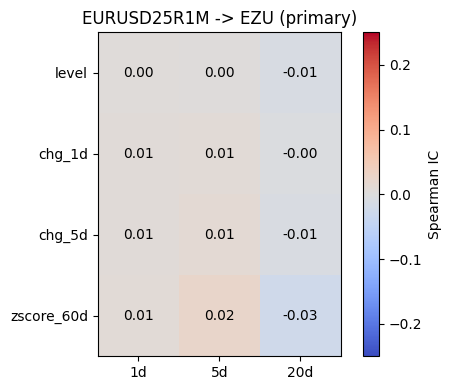

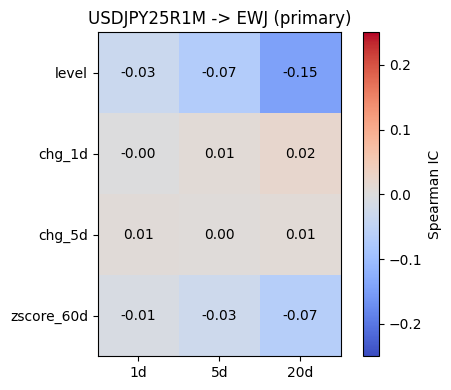

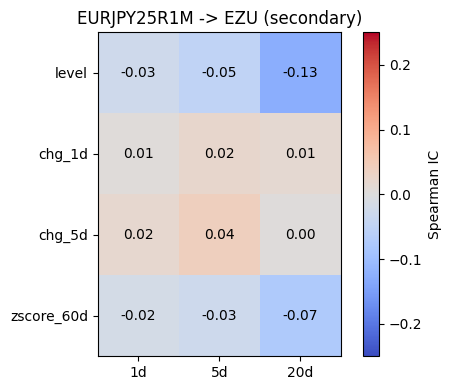

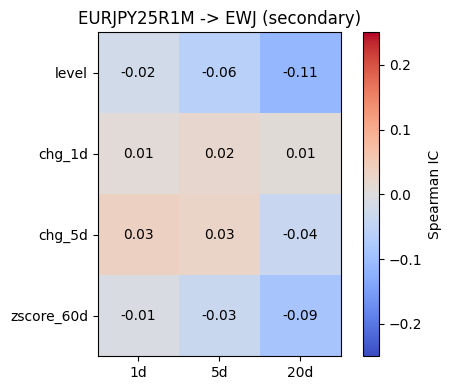

In [9]:
def plot_ic_heatmap(pair_diag, row_order, title, vmax=0.25):
    pivot = pair_diag.pivot(index="variant", columns="horizon", values="spearman_ic")
    pivot = pivot.reindex(row_order)

    fig, ax = plt.subplots(figsize=(5, 0.5 * len(row_order) + 2))

    values = pivot.to_numpy()
    image = ax.imshow(values, vmin=-vmax, vmax=vmax, cmap="coolwarm")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{h}d" for h in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center")

    fig.colorbar(image, ax=ax, label="Spearman IC")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


for rr_name, etf_name, kind in rr_pairs:
    pair_diag = rr_diagnostics[
        (rr_diagnostics["rr"] == rr_name) & (rr_diagnostics["etf"] == etf_name)
    ]
    plot_ic_heatmap(pair_diag, rr_feature_variants, f"{rr_name} -> {etf_name} ({kind})")

## Own-asset factor diagnostics

Same IC check, now for each ETF against its own price/volume/volatility-index
factors rather than a cross-asset FX signal.

In [10]:
rows = []
for etf in etf_cols:
    for variant in own_asset_feature_variants:
        fcol = f"{etf}_{variant}"
        for h in horizons:
            tcol = f"{etf}_fwd_ret_{h}d"
            paired = signals[[fcol, tcol]].dropna()
            if len(paired) < 30:
                continue

            rows.append({
                "family": "own_asset",
                "feature": fcol,
                "target": tcol,
                "etf": etf,
                "variant": variant,
                "horizon": h,
                "n": len(paired),
                "pearson_ic": paired[fcol].corr(paired[tcol]),
                "spearman_ic": paired[fcol].corr(paired[tcol], method="spearman"),
            })

own_asset_diagnostics = pd.DataFrame(rows)
own_asset_diagnostics.sort_values("spearman_ic", key=lambda s: s.abs(), ascending=False).head(15)

,family,feature,target,etf,variant,horizon,n,pearson_ic,spearman_ic
20,own_asset,SPY_volidx_level,SPY_fwd_ret_20d,SPY,volidx_level,20,3742,0.245937,0.198775
8,own_asset,SPY_mom_60d,SPY_fwd_ret_20d,SPY,mom_60d,20,3682,-0.212264,-0.161397
50,own_asset,EZU_volidx_level,EZU_fwd_ret_20d,EZU,volidx_level,20,3742,0.203764,0.158584
89,own_asset,EWJ_volidx_zscore_60d,EWJ_fwd_ret_20d,EWJ,volidx_zscore_60d,20,3713,0.146543,0.136390
11,own_asset,SPY_price_vs_sma50,SPY_fwd_ret_20d,SPY,price_vs_sma50,20,3718,-0.196297,-0.135788
19,own_asset,SPY_volidx_level,SPY_fwd_ret_5d,SPY,volidx_level,5,3757,0.104779,0.130871
49,own_asset,EZU_volidx_level,EZU_fwd_ret_5d,EZU,volidx_level,5,3757,0.097254,0.104519
5,own_asset,SPY_mom_20d,SPY_fwd_ret_20d,SPY,mom_20d,20,3722,-0.141174,-0.100120
7,own_asset,SPY_mom_60d,SPY_fwd_ret_5d,SPY,mom_60d,5,3697,-0.118536,-0.098506
59,own_asset,EZU_volidx_zscore_60d,EZU_fwd_ret_20d,EZU,volidx_zscore_60d,20,3713,0.086850,0.098293


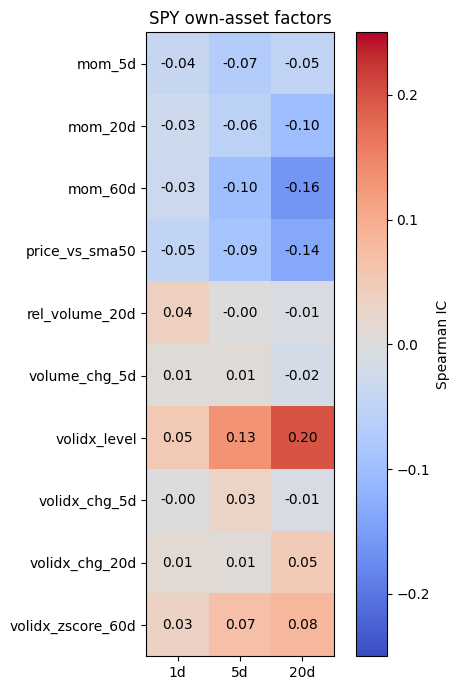

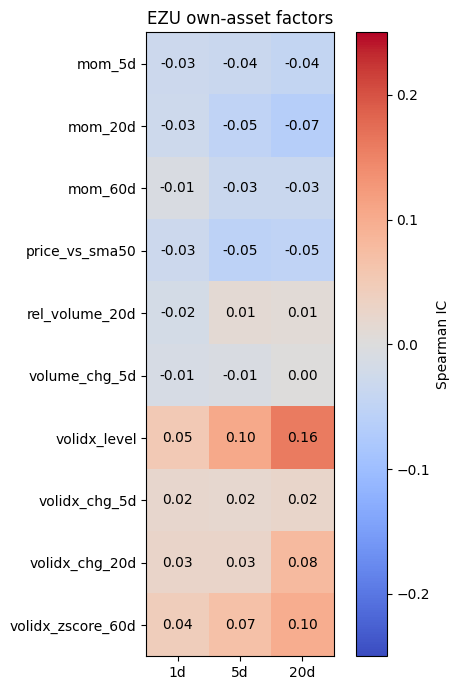

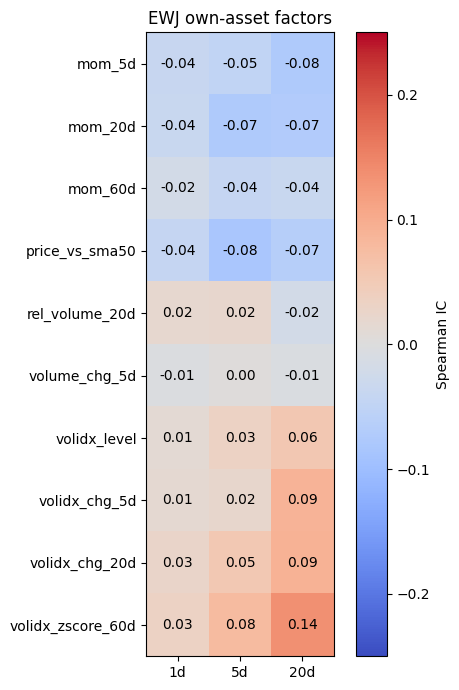

In [11]:
for etf in etf_cols:
    etf_diag = own_asset_diagnostics[own_asset_diagnostics["etf"] == etf]
    plot_ic_heatmap(etf_diag, own_asset_feature_variants, f"{etf} own-asset factors", vmax=0.25)

## Quantile buckets

For a feature/target pair, bucket the feature into quintiles and plot the
average forward return per bucket. A useful signal should show a roughly
monotonic step across buckets, not just a single significant correlation
number.

First, the two primary risk-reversal pairs at the 20-day horizon (their
best-performing transform above is `level`):

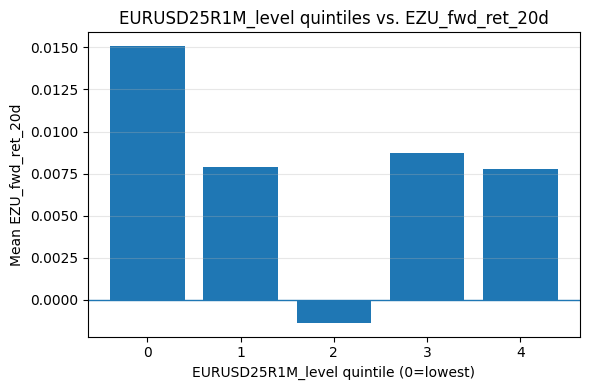

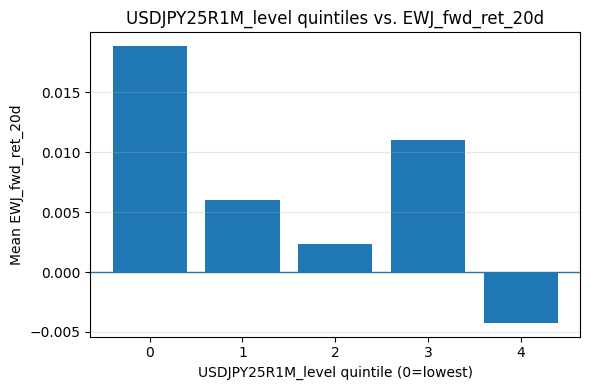

In [12]:
def plot_quantile_buckets(feature_col, target_col, n_buckets=5):
    paired = signals[[feature_col, target_col]].dropna()
    paired = paired.assign(
        bucket=pd.qcut(paired[feature_col], n_buckets, labels=False, duplicates="drop")
    )

    bucket_means = paired.groupby("bucket")[target_col].mean()

    plt.figure(figsize=(6, 4))
    plt.bar(bucket_means.index.to_numpy(), bucket_means.to_numpy())
    plt.axhline(0, linewidth=1)
    plt.xlabel(f"{feature_col} quintile (0=lowest)")
    plt.ylabel(f"Mean {target_col}")
    plt.title(f"{feature_col} quintiles vs. {target_col}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_quantile_buckets("EURUSD25R1M_level", "EZU_fwd_ret_20d")
plot_quantile_buckets("USDJPY25R1M_level", "EWJ_fwd_ret_20d")

Now the strongest results overall, picked automatically from the combined
risk-reversal and own-asset diagnostics tables (excluding the two pairs
already shown above):

In [13]:
all_diagnostics = pd.concat([rr_diagnostics, own_asset_diagnostics], ignore_index=True)

already_shown = {
    ("EURUSD25R1M_level", "EZU_fwd_ret_20d"),
    ("USDJPY25R1M_level", "EWJ_fwd_ret_20d"),
}

ranked = all_diagnostics.assign(abs_ic=all_diagnostics["spearman_ic"].abs())
ranked = ranked.sort_values("abs_ic", ascending=False)
ranked = ranked[~ranked.apply(lambda r: (r["feature"], r["target"]) in already_shown, axis=1)]

top_pairs = ranked.drop_duplicates(subset=["feature"]).head(4)
top_pairs[["family", "feature", "target", "horizon", "n", "pearson_ic", "spearman_ic"]]

,family,feature,target,horizon,n,pearson_ic,spearman_ic
68,own_asset,SPY_volidx_level,SPY_fwd_ret_20d,20,3742,0.245937,0.198775
56,own_asset,SPY_mom_60d,SPY_fwd_ret_20d,20,3682,-0.212264,-0.161397
98,own_asset,EZU_volidx_level,EZU_fwd_ret_20d,20,3742,0.203764,0.158584
137,own_asset,EWJ_volidx_zscore_60d,EWJ_fwd_ret_20d,20,3713,0.146543,0.136390


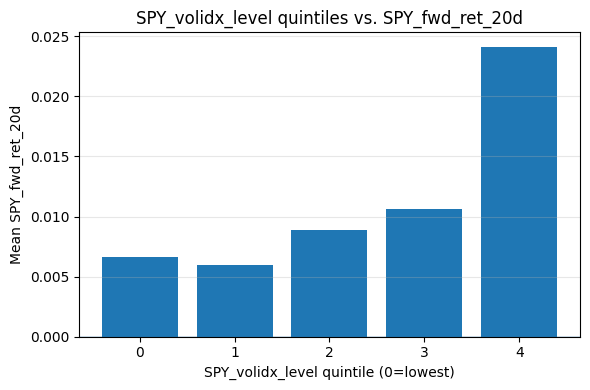

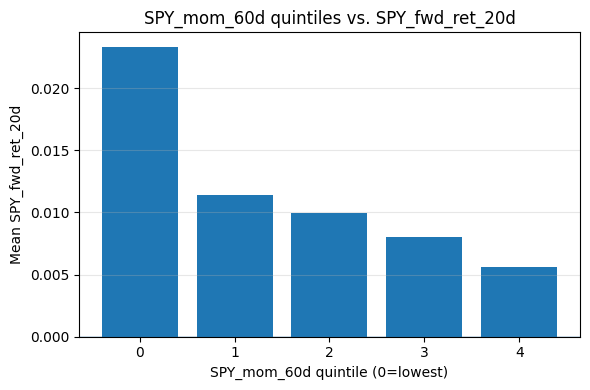

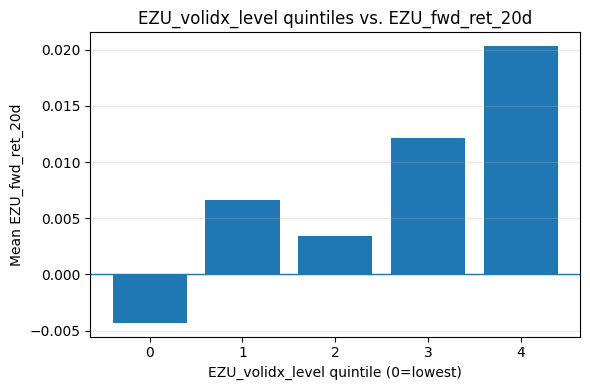

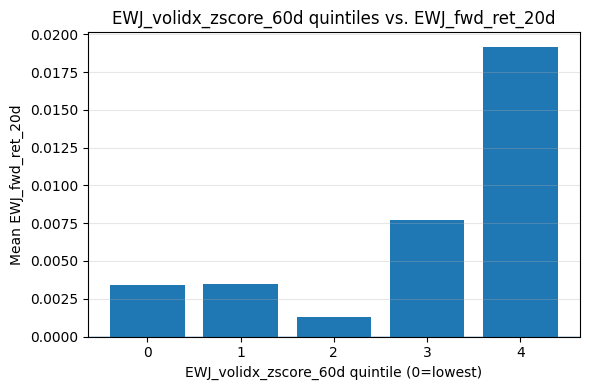

In [14]:
for _, row in top_pairs.iterrows():
    plot_quantile_buckets(row["feature"], row["target"])

## Rolling IC stability

A correlation computed over the full history can hide a relationship that
only held in one regime. Rolling 252-day (roughly 1 trading year) Pearson IC
shows whether the sign and strength of the strongest relationships found
above is stable over time or concentrated in a few episodes (e.g. 2008,
2020).

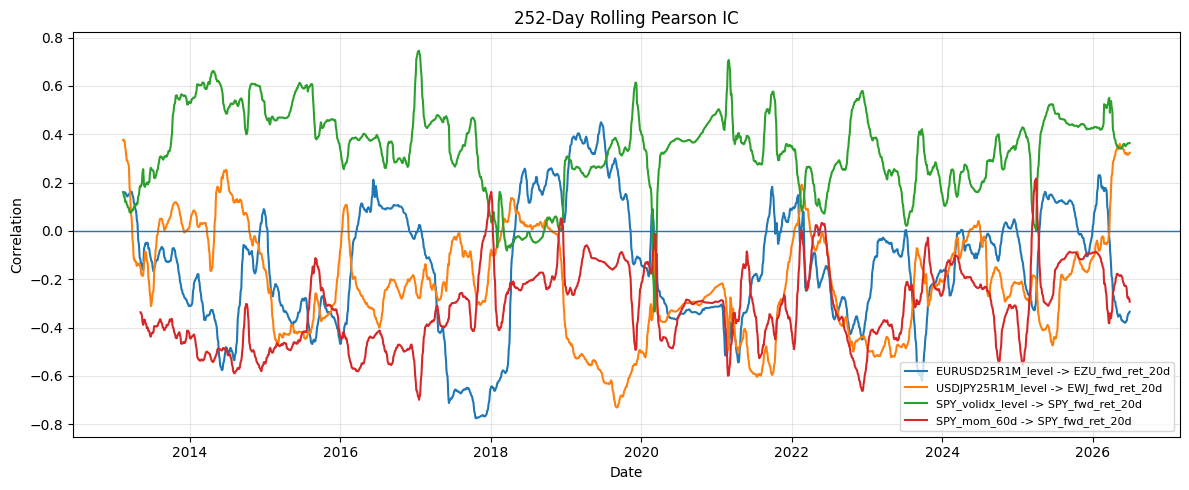

In [15]:
rolling_window = 252

rolling_pairs = [
    ("EURUSD25R1M_level", "EZU_fwd_ret_20d"),
    ("USDJPY25R1M_level", "EWJ_fwd_ret_20d"),
    ("SPY_volidx_level", "SPY_fwd_ret_20d"),
    ("SPY_mom_60d", "SPY_fwd_ret_20d"),
]

rolling_ic = pd.DataFrame(index=signals.index)
for fcol, tcol in rolling_pairs:
    rolling_ic[f"{fcol} -> {tcol}"] = (
        signals[fcol].rolling(rolling_window).corr(signals[tcol])
    )

plt.figure(figsize=(12, 5))
for col in rolling_ic.columns:
    plt.plot(rolling_ic.index.to_numpy(), rolling_ic[col].to_numpy(), label=col)

plt.axhline(0, linewidth=1)
plt.title(f"{rolling_window}-Day Rolling Pearson IC")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Single-factor takeaways

- The clearest single-factor result is the **level of each ETF's own
  volatility index** against its 20-day forward return: Spearman IC of
  about 0.20 for `SPY`/`VIX` and 0.16 for `EZU`/`V2X`. Elevated implied
  volatility is followed by higher subsequent returns — a volatility
  risk premium / mean-reversion effect, not a risk reversal or momentum
  effect.
- Own-asset **60-day momentum** and **price-vs-50-day-average** are
  negatively related to 20-day forward returns for `SPY` (IC around -0.16
  and -0.14) — i.e. a reversal rather than a continuation pattern at this
  horizon, consistent with the volatility result above (a big run-up tends
  to coincide with low vol and lower forward returns, and vice versa).
- **Volume-based factors show essentially no edge** in this sample (IC near
  zero across the board).
- The original risk-reversal pairing (`EZU`, `EWJ` only) was the weakest
  family here (|IC| mostly under 0.1). After sign-correcting to a
  consistent "local-currency-demand" framing (see that section earlier)
  and extending it to `SPY`, one new feature stands out: `SPY`'s demand-for-USD-vs-JPY proxy
  has a 20-day IC of about -0.18 to -0.21 — comparable in size to the
  volatility-index result, and the same direction (elevated JPY safe-haven
  demand precedes higher subsequent `SPY` returns — the same
  fear-precedes-recovery pattern as the `VIX` finding, just sourced from
  the FX options market instead of equity options).
- Several of these factors are likely correlated with each other (e.g.
  momentum and vol level, or `SPY`'s new JPY-demand feature and `VIX`
  level — both are risk-sentiment gauges), so their combined effect isn't
  just the sum of their individual ICs — the next section combines them
  into a proper multivariate model.

## Leakage and look-ahead bias audit

Before fitting anything, a plain-language audit of where this pipeline
could be fooling itself. Some of these are guarded against below; some are
real limitations that are easier to name than to fully fix.

1. **Feature construction — safe.** Every transform (`.rolling(w)`,
   `.diff(w)`, `.pct_change(w)`) is trailing/right-aligned by default in
   pandas; none of them use `center=True`. Nothing here can see the future.
2. **Forward-return targets — safe by design, dangerous if ever reused as a
   feature.** `price.shift(-h)` deliberately looks forward; that's the
   point of a label. The risk is a future edit accidentally feeding a
   `_fwd_ret_*` column back in as a predictor — worth checking any new
   feature doesn't do this.
3. **Train/test embargo — implemented.** `PREDICT_HORIZON` rows are dropped
   between the end of training and the start of each test period (single
   split and every walk-forward fold), so no training row's target window
   extends into the evaluation period.
4. **Scaler and hyperparameter search fit on training data only —
   implemented.** `StandardScaler` and `RidgeCV`'s internal time-series
   cross-validation never see test-period rows, in either the single split
   or the walk-forward folds.
5. **Overlapping windows inflate the diagnostics tables' apparent sample
   size — real, not fixed.** The IC and quantile-bucket sections earlier
   compute a forward return for *every* day, so adjacent rows share all but
   one day of the same return path. `n ≈ 3700` in those tables looks like
   3700 independent observations; at a 20-day horizon the effective
   independent sample size is closer to `3700 / 20 ≈ 185`. This doesn't
   leak future information, but it does make single-factor ICs look more
   statistically solid than they are.
6. **Feature and horizon selection were informed by full-sample
   statistics — the most important one, not fixed.** Choosing to model the
   20-day horizon, and to drop the 1-day/5-day feature variants, was based
   on diagnostics computed over the *entire* history — including dates that
   later became test data in every split below. The walk-forward results
   validate the fitted *coefficients* out-of-sample; they do not validate
   the decision of which horizon and features to use in the first place,
   since that decision had implicit access to the full sample. This is a
   common, easy-to-miss form of selection leakage in factor research.
7. **Same calendar date, unknown time-of-day — unverified.** The FX risk
   reversal quotes and ETF prices are joined on date only; there are no
   intraday timestamps in the source data. If a Bloomberg BGN risk-reversal
   snapshot for a given date is actually captured after the US equity close
   it's paired with, a same-day feature could quietly contain information
   from after the price it's meant to help predict. Worth confirming
   snapshot conventions with the data source before trusting a same-day
   (rather than lagged) signal.
8. **The rotation portfolio's realized return always matches the actual
   holding period, even if you decouple it from the model's horizon below —
   implemented, but easy to break.** Predictions still come from a model
   trained to predict `PREDICT_HORIZON`-ahead returns; the portfolio's
   *realized* return is computed separately for whatever `REBALANCE_EVERY`
   is set to. Setting them to different values is a legitimate design
   choice (trading a stale or fresher signal than its native horizon), not
   a bug — just be aware of which one you're doing.

## Backtest configuration

Everything from here on — the multivariate model, walk-forward validation,
and rotation portfolio — is driven entirely by the parameters in the next
cell. Change these to try a different horizon, drop a factor family, widen
the regularization search, or rebalance on a different cadence than the
model's own forecast horizon, without touching any logic further down.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import spearmanr

# ---- What the model is trained to predict ----
PREDICT_HORIZON = 20          # forward-return horizon in trading days (try 1, 5, 20, or any custom value)

# ---- Which factor families to include per ETF ----
INCLUDE_MOMENTUM = True       # mom_20d, mom_60d
INCLUDE_TREND = True          # price_vs_sma50
INCLUDE_VOLUME = True         # rel_volume_20d
INCLUDE_VOLIDX = True         # volidx_level, volidx_chg_20d, volidx_zscore_60d
INCLUDE_RISK_REVERSAL = True  # local-currency-demand RR feature(s), now for all three ETFs

# ---- Single train/test split ----
TRAIN_FRACTION = 0.8          # fraction of history used for training

# ---- Walk-forward validation ----
N_WALKFORWARD_FOLDS = 5

# ---- Ridge regularization search ----
ALPHA_GRID = np.logspace(-2, 6, 40)

# ---- Rotation portfolio ----
# How often the portfolio actually rebalances. Independent of PREDICT_HORIZON:
# e.g. rebalance every 5 days on a model trained to predict 20-day-ahead
# returns is a legitimate (if untested-here) design choice, not an error.
REBALANCE_EVERY = 20

# Both RR features named "_ccy_demand" for each ETF, from the local-currency-
# demand construction above — now defined for all three ETFs, not just EZU/EWJ.
RISK_REVERSAL_PAIRING = {
    etf: [f"{etf}_{rr_name}_ccy_demand" for rr_name in pairs]
    for etf, pairs in LOCAL_CURRENCY_RR_PAIRS.items()
}


def build_feature_set(etf):
    cols = []
    if INCLUDE_MOMENTUM:
        cols += [f"{etf}_mom_20d", f"{etf}_mom_60d"]
    if INCLUDE_TREND:
        cols.append(f"{etf}_price_vs_sma50")
    if INCLUDE_VOLUME:
        cols.append(f"{etf}_rel_volume_20d")
    if INCLUDE_VOLIDX:
        cols += [f"{etf}_volidx_level", f"{etf}_volidx_chg_20d", f"{etf}_volidx_zscore_60d"]
    if INCLUDE_RISK_REVERSAL:
        cols += RISK_REVERSAL_PAIRING.get(etf, [])
    return cols


def forward_return(etf, days):
    """Actual (not predicted) return from today's close to `days` trading days ahead."""
    price = df[etf_cols[etf]["price"]]
    return price.shift(-days) / price - 1


model_feature_sets = {etf: build_feature_set(etf) for etf in etf_cols}
model_feature_sets

{'SPY': ['SPY_mom_20d',
  'SPY_mom_60d',
  'SPY_price_vs_sma50',
  'SPY_rel_volume_20d',
  'SPY_volidx_level',
  'SPY_volidx_chg_20d',
  'SPY_volidx_zscore_60d',
  'SPY_EURUSD25R1M_ccy_demand',
  'SPY_USDJPY25R1M_ccy_demand'],
 'EZU': ['EZU_mom_20d',
  'EZU_mom_60d',
  'EZU_price_vs_sma50',
  'EZU_rel_volume_20d',
  'EZU_volidx_level',
  'EZU_volidx_chg_20d',
  'EZU_volidx_zscore_60d',
  'EZU_EURUSD25R1M_ccy_demand',
  'EZU_EURJPY25R1M_ccy_demand'],
 'EWJ': ['EWJ_mom_20d',
  'EWJ_mom_60d',
  'EWJ_price_vs_sma50',
  'EWJ_rel_volume_20d',
  'EWJ_volidx_level',
  'EWJ_volidx_chg_20d',
  'EWJ_volidx_zscore_60d',
  'EWJ_USDJPY25R1M_ccy_demand',
  'EWJ_EURJPY25R1M_ccy_demand']}

## Multivariate model

One Ridge (L2-regularized linear) regression per ETF, predicting its
`PREDICT_HORIZON`-day forward return from the feature set configured above.

Ridge rather than plain OLS because several of these features are
correlated with each other (e.g. momentum and trend, vol-index level and
its own z-score); the L2 penalty shrinks the coefficients instead of
letting collinearity blow up their variance. Features are standardized
(fit on the training set only), and the penalty strength (`alpha`) is chosen
by time-series cross-validation *within* the training set, so the test set
is never touched during model selection.

The split is chronological (never randomized, since this is time series):
`TRAIN_FRACTION` train / remainder test by row count, with a
`PREDICT_HORIZON`-day embargo removed from the end of train so no training
row's forward-return window overlaps the test period.

In [17]:
model_results = {}

for etf, feature_cols in model_feature_sets.items():
    target_col = f"{etf}_fwd_ret_{PREDICT_HORIZON}d"
    target = forward_return(etf, PREDICT_HORIZON).rename(target_col)
    data = pd.concat([features[feature_cols], target], axis=1).dropna().sort_index()

    n = len(data)
    train_end = int(n * TRAIN_FRACTION) - PREDICT_HORIZON
    test_start = int(n * TRAIN_FRACTION)

    train = data.iloc[:train_end]
    test = data.iloc[test_start:]

    scaler = StandardScaler().fit(train[feature_cols])
    X_train = scaler.transform(train[feature_cols])
    X_test = scaler.transform(test[feature_cols])
    y_train = train[target_col].to_numpy()
    y_test = test[target_col].to_numpy()

    model = RidgeCV(alphas=ALPHA_GRID, cv=TimeSeriesSplit(5)).fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    model_results[etf] = {
        "feature_cols": feature_cols,
        "target_col": target_col,
        "train": train,
        "test": test,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "alpha": model.alpha_,
        "r2_train": model.score(X_train, y_train),
        "r2_test": model.score(X_test, y_test),
        "ic_train": spearmanr(pred_train, y_train).correlation,
        "ic_test": spearmanr(pred_test, y_test).correlation,
        "coefs": pd.Series(model.coef_, index=feature_cols)
            .sort_values(key=np.abs, ascending=False),
    }

summary = pd.DataFrame({
    etf: {
        "n_train": len(r["train"]), "n_test": len(r["test"]), "alpha": r["alpha"],
        "r2_train": r["r2_train"], "r2_test": r["r2_test"],
        "ic_train": r["ic_train"], "ic_test": r["ic_test"],
    }
    for etf, r in model_results.items()
}).T
summary

,n_train,n_test,alpha,r2_train,r2_test,ic_train,ic_test
SPY,2925.0,737.0,3455.107295,0.076036,0.021165,0.257182,0.077468
EZU,2925.0,737.0,5541.020330,0.051010,-0.018855,0.195856,0.125329
EWJ,2925.0,737.0,14251.026703,0.033276,-0.017300,0.176457,0.050555


Standardized coefficients, largest magnitude first, for each ETF's model:

In [18]:
for etf, r in model_results.items():
    print(f"--- {etf} (alpha={r['alpha']:.1f}) ---")
    print(r["coefs"].to_string())
    print()

--- SPY (alpha=3455.1) ---
SPY_volidx_level              0.002741
SPY_USDJPY25R1M_ccy_demand   -0.002504
SPY_mom_60d                  -0.002385
SPY_price_vs_sma50           -0.001899
SPY_mom_20d                  -0.001180
SPY_rel_volume_20d           -0.001180
SPY_volidx_zscore_60d        -0.000417
SPY_volidx_chg_20d            0.000280
SPY_EURUSD25R1M_ccy_demand    0.000256

--- EZU (alpha=5541.0) ---
EZU_volidx_level              0.003272
EZU_EURJPY25R1M_ccy_demand   -0.003219
EZU_EURUSD25R1M_ccy_demand   -0.001600
EZU_mom_20d                  -0.000661
EZU_volidx_zscore_60d         0.000392
EZU_rel_volume_20d           -0.000356
EZU_mom_60d                   0.000256
EZU_volidx_chg_20d            0.000237
EZU_price_vs_sma50           -0.000158

--- EWJ (alpha=14251.0) ---
EWJ_EURJPY25R1M_ccy_demand    0.001349
EWJ_USDJPY25R1M_ccy_demand    0.000960
EWJ_volidx_chg_20d            0.000899
EWJ_volidx_level              0.000592
EWJ_volidx_zscore_60d         0.000579
EWJ_mom_20d        

### Out-of-sample fit

Quintile buckets of the *test-set* predictions vs. actual forward returns
for each ETF — the real test of whether the model's ranking of high vs.
low predicted return corresponds to anything in data it never trained on.

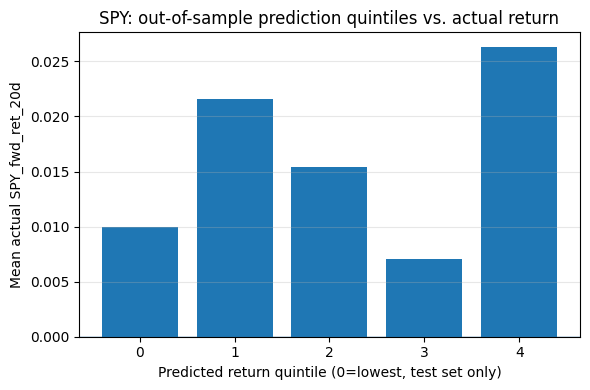

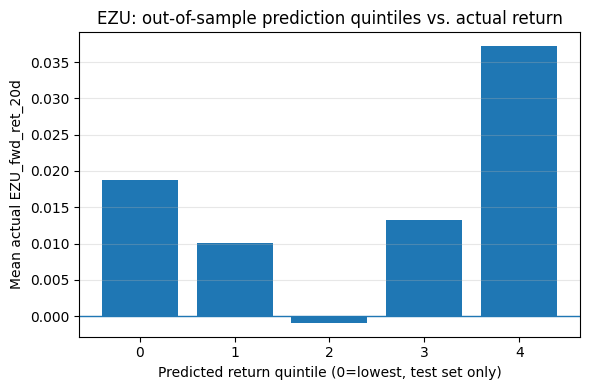

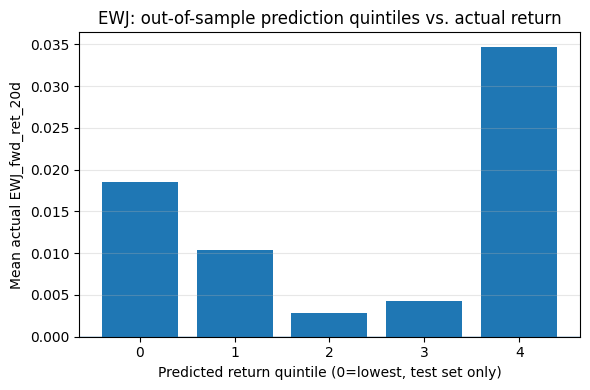

In [19]:
for etf, r in model_results.items():
    target_col = r["target_col"]
    test_eval = r["test"][[target_col]].copy()
    test_eval["predicted"] = r["pred_test"]

    plt.figure(figsize=(6, 4))
    bucket = pd.qcut(test_eval["predicted"], 5, labels=False, duplicates="drop")
    bucket_means = test_eval.groupby(bucket)[target_col].mean()

    plt.bar(bucket_means.index.to_numpy(), bucket_means.to_numpy())
    plt.axhline(0, linewidth=1)
    plt.xlabel("Predicted return quintile (0=lowest, test set only)")
    plt.ylabel(f"Mean actual {target_col}")
    plt.title(f"{etf}: out-of-sample prediction quintiles vs. actual return")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

### Robustness check: walk-forward validation

A single 80/20 split is one draw from history — it can look good or bad
just because of which regime ended up in the test window. Walk-forward
(expanding-window) validation refits the model 5 times, each time training
on everything up to a point and testing on the next slice, so every part of
history gets evaluated out-of-sample exactly once.

In [20]:
walkforward_results = {}

for etf, feature_cols in model_feature_sets.items():
    target_col = f"{etf}_fwd_ret_{PREDICT_HORIZON}d"
    target = forward_return(etf, PREDICT_HORIZON).rename(target_col)
    data = pd.concat([features[feature_cols], target], axis=1).dropna().sort_index()
    n = len(data)

    fold_bounds = np.linspace(0, n, N_WALKFORWARD_FOLDS + 2).astype(int)
    fold_records = []
    all_pred, all_actual = [], []

    for i in range(1, N_WALKFORWARD_FOLDS + 1):
        train_end = fold_bounds[i] - PREDICT_HORIZON
        test_start, test_end = fold_bounds[i], fold_bounds[i + 1]

        train = data.iloc[:train_end]
        test = data.iloc[test_start:test_end]

        scaler = StandardScaler().fit(train[feature_cols])
        X_train, X_test = scaler.transform(train[feature_cols]), scaler.transform(test[feature_cols])
        y_train, y_test = train[target_col].to_numpy(), test[target_col].to_numpy()

        model = RidgeCV(alphas=ALPHA_GRID, cv=TimeSeriesSplit(4)).fit(X_train, y_train)
        pred = model.predict(X_test)
        ic = spearmanr(pred, y_test).correlation

        fold_records.append({
            "fold": i,
            "test_start": test.index.min(), "test_end": test.index.max(),
            "n_test": len(test), "alpha": model.alpha_, "ic": ic,
        })
        all_pred.append(pred)
        all_actual.append(y_test)

    walkforward_results[etf] = {
        "folds": pd.DataFrame(fold_records),
        "pooled_ic": spearmanr(np.concatenate(all_pred), np.concatenate(all_actual)).correlation,
    }

for etf, r in walkforward_results.items():
    print(f"--- {etf} ---")
    print(r["folds"].to_string(index=False))
    print(f"mean fold IC = {r['folds']['ic'].mean():.4f}  "
          f"std = {r['folds']['ic'].std():.4f}  "
          f"pooled IC = {r['pooled_ic']:.4f}")
    print()

--- SPY ---
 fold test_start   test_end  n_test       alpha       ic
    1 2014-09-25 2017-01-31     614 2154.434690 0.237635
    2 2017-02-01 2019-06-10     614 1343.399333 0.074341
    3 2019-06-11 2021-10-14     613 3455.107295 0.368116
    4 2021-10-15 2024-02-21     614 2154.434690 0.083588
    5 2024-02-22 2026-06-30     614 3455.107295 0.169056
mean fold IC = 0.1865  std = 0.1215  pooled IC = 0.0975

--- EZU ---
 fold test_start   test_end  n_test        alpha       ic
    1 2014-09-25 2017-01-31     614   126.638017 0.168564
    2 2017-02-01 2019-06-10     614 14251.026703 0.077569
    3 2019-06-11 2021-10-14     613  5541.020330 0.390551
    4 2021-10-15 2024-02-21     614  5541.020330 0.028533
    5 2024-02-22 2026-06-30     614  2154.434690 0.187355
mean fold IC = 0.1705  std = 0.1392  pooled IC = 0.0403

--- EWJ ---
 fold test_start   test_end  n_test          alpha        ic
    1 2014-09-25 2017-01-31     614 1000000.000000  0.038918
    2 2017-02-01 2019-06-10     614   

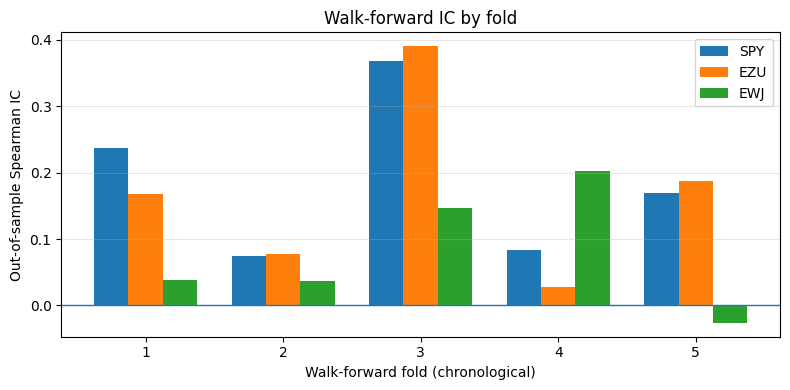

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.25
for offset, (etf, r) in zip([-width, 0, width], walkforward_results.items()):
    folds = r["folds"]
    ax.bar(folds["fold"].to_numpy() + offset, folds["ic"].to_numpy(), width=width, label=etf)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Walk-forward fold (chronological)")
ax.set_ylabel("Out-of-sample Spearman IC")
ax.set_title("Walk-forward IC by fold")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Single-asset rotation portfolio

Everything so far treated each ETF's model in isolation. Now: given the
constraint of holding exactly **one of the three ETFs at a time**, use the
models to pick which one, and see whether that selection actually adds
value over simpler alternatives.

Approach:

- Reuse the walk-forward setup above (not the single 80/20 split) so every
  prediction used to pick an asset is genuinely out-of-sample at the time
  it would have been made. These predictions target `PREDICT_HORIZON`-day
  forward returns.
- Rebalance every `REBALANCE_EVERY` trading days — independent of
  `PREDICT_HORIZON` (leakage point #8 in the audit above): at each
  rebalance date, take each ETF's predicted `PREDICT_HORIZON`-day forward
  return and hold whichever is highest, but *measure* the strategy's actual
  return over the real `REBALANCE_EVERY`-day holding period, not over
  `PREDICT_HORIZON`. With the defaults the two are equal (20 = 20), so
  holding periods don't overlap; setting `REBALANCE_EVERY` lower than
  `PREDICT_HORIZON` means trading a signal more often than its own horizon
  (each rebalance overlaps the previous holding period), and setting it
  higher means trading a staler signal.
- Compare against: an **oracle** that picks whichever ETF actually had the
  best realized return each period (a look-ahead upper bound, not a real
  strategy), **equal-weight** across all three, and buying and holding each
  ETF individually.

In [22]:
pred_series = {}

for etf, feature_cols in model_feature_sets.items():
    target_col = f"{etf}_fwd_ret_{PREDICT_HORIZON}d"
    target = forward_return(etf, PREDICT_HORIZON).rename(target_col)
    data = pd.concat([features[feature_cols], target], axis=1).dropna().sort_index()
    n = len(data)
    fold_bounds = np.linspace(0, n, N_WALKFORWARD_FOLDS + 2).astype(int)

    fold_preds = []
    for i in range(1, N_WALKFORWARD_FOLDS + 1):
        train_end = fold_bounds[i] - PREDICT_HORIZON
        test_start, test_end = fold_bounds[i], fold_bounds[i + 1]

        train = data.iloc[:train_end]
        test = data.iloc[test_start:test_end]

        scaler = StandardScaler().fit(train[feature_cols])
        X_train, X_test = scaler.transform(train[feature_cols]), scaler.transform(test[feature_cols])
        y_train = train[target_col].to_numpy()

        model = RidgeCV(alphas=ALPHA_GRID, cv=TimeSeriesSplit(4)).fit(X_train, y_train)
        fold_preds.append(pd.Series(model.predict(X_test), index=test.index))

    pred_series[etf] = pd.concat(fold_preds)

pred_df = pd.DataFrame(pred_series).dropna()

# Actual holding-period return, computed independently at REBALANCE_EVERY —
# not assumed to equal PREDICT_HORIZON.
actual_returns = pd.DataFrame({etf: forward_return(etf, REBALANCE_EVERY) for etf in model_feature_sets})

rebalance_dates = pred_df.index[::REBALANCE_EVERY]
rebalance_dates = rebalance_dates[actual_returns.loc[rebalance_dates].notna().all(axis=1)]
actual_df = actual_returns.loc[rebalance_dates]

print(f"{len(rebalance_dates)} rebalance periods every {REBALANCE_EVERY} trading days "
      f"(model trained on a {PREDICT_HORIZON}-day horizon), "
      f"{rebalance_dates.min().date()} to {rebalance_dates.max().date()}")

154 rebalance periods every 20 trading days (model trained on a 20-day horizon), 2014-09-25 to 2026-06-18


In [23]:
chosen = pred_df.loc[rebalance_dates].idxmax(axis=1)
oracle_chosen = actual_df.loc[rebalance_dates].idxmax(axis=1)

realized = pd.Series(
    [actual_df.loc[d, chosen.loc[d]] for d in rebalance_dates], index=rebalance_dates
)
oracle_realized = pd.Series(
    [actual_df.loc[d, oracle_chosen.loc[d]] for d in rebalance_dates], index=rebalance_dates
)
equal_weight = actual_df.loc[rebalance_dates].mean(axis=1)

hit_rate = (chosen == oracle_chosen).mean()
switch_rate = (chosen != chosen.shift(1)).mean()

print("model's asset choice, by count:")
print(chosen.value_counts())
print()
print("actual best asset (oracle), by count:")
print(oracle_chosen.value_counts())
print()
print(f"hit rate vs. oracle: {hit_rate:.3f}  (random chance with 3 assets = 0.333)")
print(f"period-to-period switch rate: {switch_rate:.3f}")

model's asset choice, by count:
SPY    96
EZU    31
EWJ    27
Name: count, dtype: int64

actual best asset (oracle), by count:
SPY    68
EZU    47
EWJ    39
Name: count, dtype: int64

hit rate vs. oracle: 0.390  (random chance with 3 assets = 0.333)
period-to-period switch rate: 0.253


### Performance

Growth of $1, and standard return/risk stats, for the model's rotation
strategy against the oracle upper bound, equal-weight, and each ETF held
alone.

In [24]:
def portfolio_stats(returns, periods_per_year=252 / REBALANCE_EVERY):
    growth = (1 + returns).cumprod()
    total_return = growth.iloc[-1] - 1
    ann_return = growth.iloc[-1] ** (periods_per_year / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    max_drawdown = (growth / growth.cummax() - 1).min()
    return pd.Series({
        "total_return": total_return, "ann_return": ann_return,
        "ann_vol": ann_vol, "sharpe": sharpe, "max_drawdown": max_drawdown,
    })


strategies = {
    "model_rotation": realized,
    "oracle_rotation": oracle_realized,
    "equal_weight": equal_weight,
    "SPY_only": actual_df.loc[rebalance_dates, "SPY"],
    "EZU_only": actual_df.loc[rebalance_dates, "EZU"],
    "EWJ_only": actual_df.loc[rebalance_dates, "EWJ"],
}

performance = pd.DataFrame({name: portfolio_stats(r) for name, r in strategies.items()}).T
performance

,total_return,ann_return,ann_vol,sharpe,max_drawdown
model_rotation,2.689926,0.112737,0.152646,0.738547,-0.241540
oracle_rotation,41.327719,0.358587,0.150559,2.381707,-0.187650
equal_weight,2.085683,0.096574,0.143678,0.672155,-0.271907
SPY_only,3.654502,0.134081,0.142726,0.939433,-0.241540
EZU_only,1.416431,0.074857,0.172966,0.432784,-0.329768
EWJ_only,1.434844,0.075525,0.151969,0.496973,-0.319804


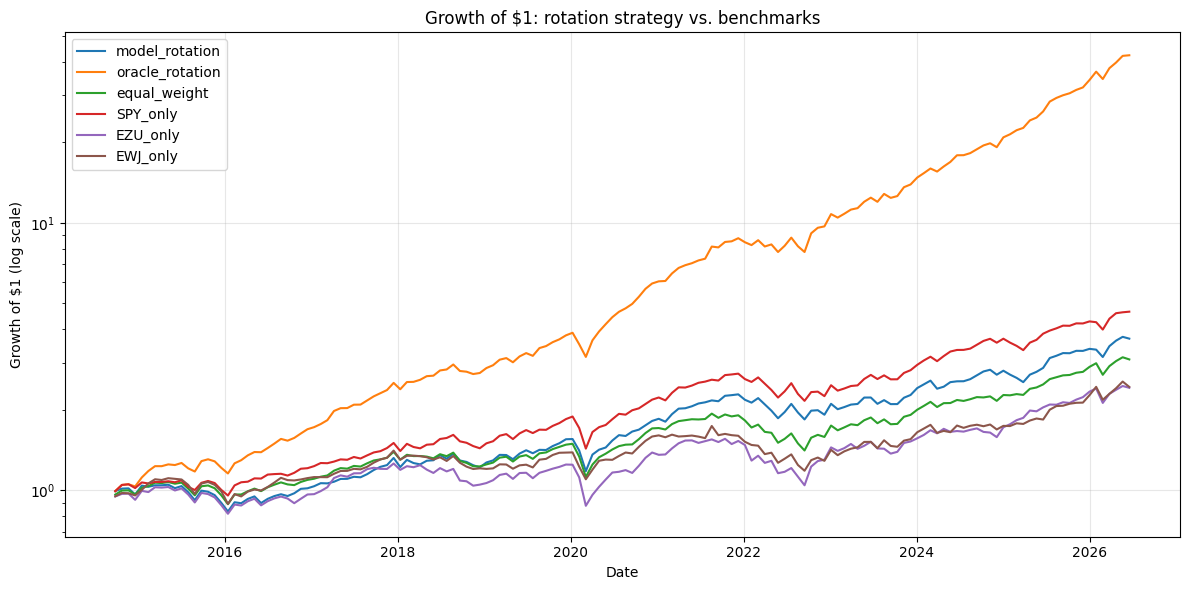

In [25]:
plt.figure(figsize=(12, 6))
for name, r in strategies.items():
    growth = (1 + r).cumprod()
    plt.plot(growth.index.to_numpy(), growth.to_numpy(), label=name)

plt.title("Growth of $1: rotation strategy vs. benchmarks")
plt.xlabel("Date")
plt.ylabel("Growth of $1 (log scale)")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

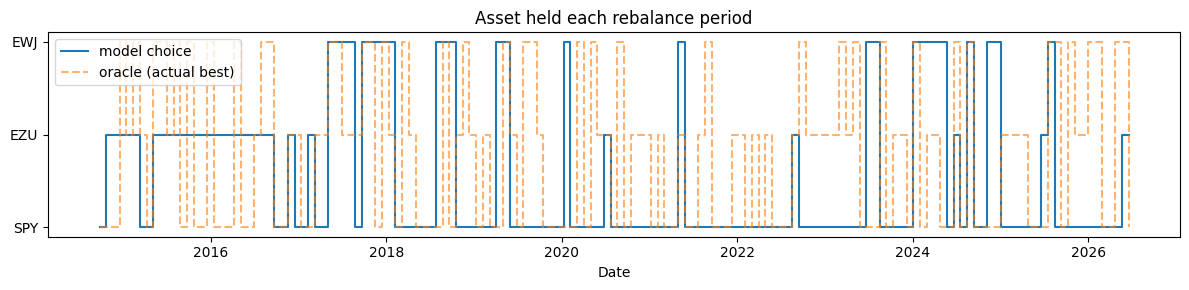

In [26]:
asset_codes = {"SPY": 0, "EZU": 1, "EWJ": 2}

plt.figure(figsize=(12, 3))
plt.step(chosen.index.to_numpy(), chosen.map(asset_codes).to_numpy(), where="post", label="model choice")
plt.step(oracle_chosen.index.to_numpy(), oracle_chosen.map(asset_codes).to_numpy(),
         where="post", linestyle="--", alpha=0.6, label="oracle (actual best)")
plt.yticks(list(asset_codes.values()), list(asset_codes.keys()))
plt.title("Asset held each rebalance period")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## Next steps

- **The local-currency-demand sign correction is conceptually validated,
  but didn’t move the model much.** Sign-correcting the risk-reversal
  features and extending them to `SPY` surfaced a genuinely interesting
  standalone factor (`SPY`'s demand-for-USD-vs-JPY proxy, IC ≈ -0.18 to
  -0.21 at 20 days). But once it sits alongside `SPY`'s own volatility
  index in the multivariate model, the walk-forward and rotation results
  barely change (`SPY` mean fold IC 0.184 -> 0.187; rotation annualized
  return 11.6% -> 11.3%). Ridge is doing its job here — it's not that the
  feature is wrong, it's that it's largely redundant with the risk-sentiment
  information `VIX` level already supplies, so it adds little on top.
- **Out-of-sample signal is real but modest, and uneven across ETFs.**
  Walk-forward mean fold IC is positive for all three (`SPY` ≈ 0.19,
  `EZU` ≈ 0.17, `EWJ` ≈ 0.08), but fold-to-fold standard deviation is
  almost as large as the mean (≈ 0.09–0.14) — some folds are strongly
  positive, at least one per ETF is close to zero or negative. This is a
  regime-dependent edge, not a stable one.
- **Pooled out-of-sample IC (all folds' predictions and actuals combined)
  is much weaker than the average per-fold IC** for every ETF. Each fold
  refits its own scaler and coefficients to that period's regime, so
  predictions aren't on a consistent enough scale across regimes to pool
  cleanly — a sign that a single global linear model isn't capturing
  something stable across the full 2012–2026 history.
- The single 80/20 split told a rosier story for `SPY`/`EZU` and a bleaker
  one for `EWJ` than the fuller walk-forward picture — a reminder not to
  trust one split's numbers on their own.
- `EWJ` is the weakest of the three throughout: its walk-forward IC is
  lower and noisier, and its local-currency-demand features (`USDJPY25R1M`,
  `EURJPY25R1M`, both re-signed as "demand for JPY") remain the weakest
  single-factor family even after the correction.
- **The single-asset rotation portfolio does not beat simply buying and
  holding `SPY`.** Model rotation returns roughly 11% annualized
  (Sharpe ~0.74) versus `SPY` buy-and-hold at roughly 13% (Sharpe
  ~0.94). It does beat equal-weight and holding `EZU` or `EWJ` alone, so
  the selection isn't worthless, but the bar that actually matters here
  (the simplest available alternative) isn't cleared.
- **Hit rate versus the oracle is barely above chance.** With three assets,
  random selection gets the actual best performer right 1-in-3 of the
  time; the model gets it right about 39% of the time, and — tellingly —
  still worse than the naive rule "always hold `SPY`" would have scored,
  because `SPY` was the realized best performer in a large plurality of
  periods in this sample. Predicting *which* of three correlated equity
  ETFs will win each period is a harder task than predicting each one's own
  return sign in isolation, and the current factor set isn't clearing that
  higher bar.
- **The oracle's Sharpe (~2.4) shows real prize money is on the table** —
  the three ETFs do diverge enough period to period that a genuinely
  better selection signal would be worth having. The gap between oracle
  and model performance is the honest measure of how much room is left.
- None of this includes transaction costs, and the 20-day non-overlapping
  rebalance is a simplification (real-time decisions could reassess daily).
- Candidate next steps: (1) try a simpler, lower-variance feature set (e.g.
  just `volidx_level` and one momentum term) to see if dropping noisier
  features improves stability rather than in-sample fit; (2) add a
  transaction-cost estimate to the rotation backtest so turnover is priced
  in, not just IC; (3) investigate whether `EWJ`'s weaker result is a
  genuine cross-asset gap or a sign the JPY-related features need rework;
  (4) since the rotation signal underperforms a naive `SPY`-only rule,
  consider whether the honest conclusion is that these three factor
  families don't yet support active rotation among these specific ETFs,
  rather than continuing to tune the current approach.